# Clinical Appointment No-Show Prediction (Milestone 1)
This is a binary classification problem where the target variable indicates whether a patient will attend (0) or not attend (1).


This notebook implements a machine learning system to predict patient appointment no-shows using classical ML models.

Models Used:
- Logistic Regression
- Decision Tree (Tuned)
- Random Forest

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC


# Datset Loading and Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [2]:
df = pd.read_csv("KaggleV2-May-2016-v2.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,0.0,1.0,0.0,0.0,0.0,0.0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0.0,0.0,0.0,0.0,0.0,0.0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0.0,0.0,0.0,0.0,0.0,0.0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0.0,0.0,0.0,0.0,0.0,0.0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0.0,1.0,1.0,0.0,0.0,0.0,No


# EDA

In [3]:
df.shape

(110527, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          106660 non-null  object 
 3   ScheduledDay    106638 non-null  object 
 4   AppointmentDay  106707 non-null  object 
 5   Age             106702 non-null  float64
 6   Neighbourhood   106635 non-null  object 
 7   Scholarship     106752 non-null  float64
 8   Hipertension    106712 non-null  float64
 9   Diabetes        106709 non-null  float64
 10  Alcoholism      106764 non-null  float64
 11  Handcap         106693 non-null  float64
 12  SMS_received    106702 non-null  float64
 13  No-show         106673 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 11.8+ MB


Missing Values

In [5]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,3867
ScheduledDay,3889
AppointmentDay,3820
Age,3825
Neighbourhood,3892
Scholarship,3775
Hipertension,3815
Diabetes,3818


Target Distribution

Dataset is imbalanced.
Accuracy alone is misleading.

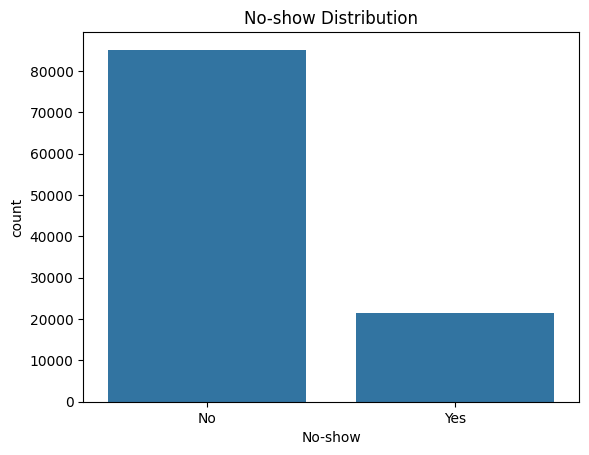


Class Distribution:
 No-show
No     0.79785
Yes    0.20215
Name: proportion, dtype: float64


In [6]:
sns.countplot(x='No-show', data=df)
plt.title("No-show Distribution")
plt.show()

print("\nClass Distribution:\n", df['No-show'].value_counts(normalize=True))

Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

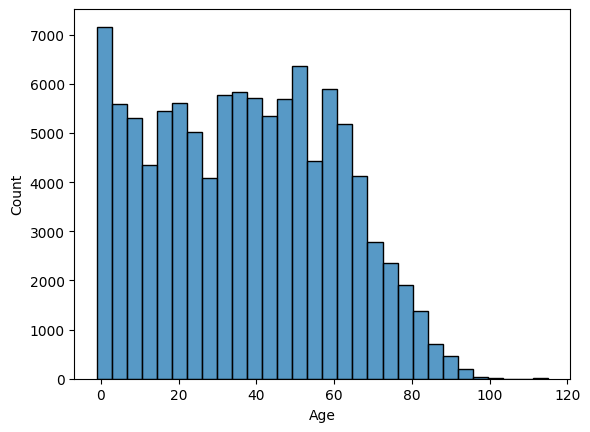

In [7]:
sns.histplot(df['Age'], bins=30)

# Pre-processing and Feature Engineering

Handling missing values

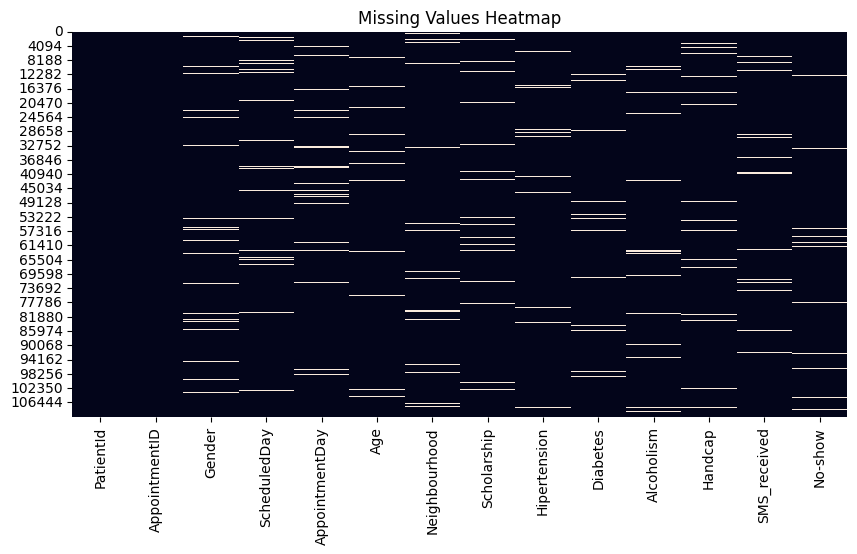

In [8]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

We use median for numerical columns because it is robust to outliers.

We use mode for categorical columns because it preserves most frequent category.

We avoid dropping rows to retain maximum data.

In [9]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical columns → fill with median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Categorical columns → fill with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


/tmp/ipython-input-219/3246859186.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-219/3246859186.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [10]:
# Remove invalid age
df = df[df['Age'] >= 0]

In [11]:
# Dropping Irrelevant Columns
# IDs do not contribute to prediction and may cause data leakage.
df = df.drop(['PatientId', 'AppointmentID'], axis=1)

In [12]:
# Convert Dates
# Lead time reflects scheduling delay and is strongly correlated with no-shows.
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [13]:
# Waiting Days
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [14]:
# Day of the week
df['appointment_day_of_week'] = df['AppointmentDay'].dt.dayofweek

In [15]:
# Dropping original Date Column
df = df.drop(['ScheduledDay', 'AppointmentDay'], axis=1)

In [16]:
# Encode Target (Convert Target to Binary)
# 1 = No-show
# 0 = Show
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

In [17]:
# Encode Gender
df['Gender'] = df['Gender'].map({'M':1, 'F':0})

In [18]:
# Drop Neighbourhood
df = df.drop('Neighbourhood', axis=1)

In [19]:
df['No-show'].value_counts()

,count
No-show,
0,88962
1,21564


In [20]:
# Split Data
X = df.drop('No-show', axis=1)
y = df['No-show']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

The dataset is imbalanced, with significantly more patients attending appointments than missing them.
Therefore, we use F1-score and Recall as primary evaluation metrics instead of Accuracy.

In [21]:
print("Class Distribution:")
print(y.value_counts())
print("\nPercentage:")
print(y.value_counts(normalize=True) * 100)

Class Distribution:
No-show
0    88962
1    21564
Name: count, dtype: int64

Percentage:
No-show
0    80.489659
1    19.510341
Name: proportion, dtype: float64


In [22]:
# Scale Numeric Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models


In [23]:
# Model 1: Logistic Regression
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [24]:
# Model 2: Decision Tree
tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

In [25]:
# Model 3: Random Forest
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Hyperparameter Tuning

In [26]:
# GridSearchCV for Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

best_tree_model = grid_dt.best_estimator_

print("Best Decision Tree Parameters:", grid_dt.best_params_)

Best Decision Tree Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [27]:
# GridSearchCV for Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [5, 10],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf_model = grid_rf.best_estimator_

print("Best Random Forest Parameters:", grid_rf.best_params_)

Best Random Forest Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [28]:
# Predictions using Tuned Models

# Decision Tree (Tuned)
y_pred_tree_tuned = best_tree_model.predict(X_test)
y_prob_tree_tuned = best_tree_model.predict_proba(X_test)[:, 1]

# Random Forest (Tuned)
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Model Evaluation

===== Logistic Regression =====
Accuracy: 0.6528996652492536
Precision: 0.29386503067484665
Recall: 0.5552979364711338
F1 Score: 0.38433763941266147
ROC-AUC: 0.6583926244894056


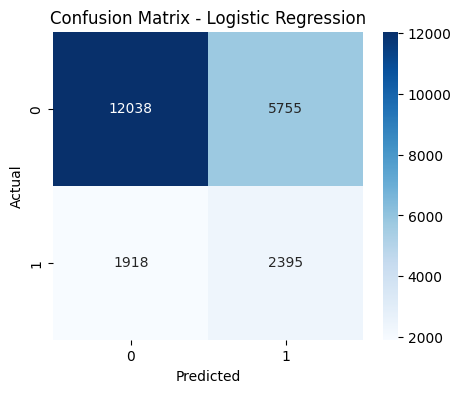



===== Decision Tree =====
Accuracy: 0.6778702614674749
Precision: 0.27714285714285714
Recall: 0.4048226292603756
F1 Score: 0.32903043437293883
ROC-AUC: 0.5450000077533311


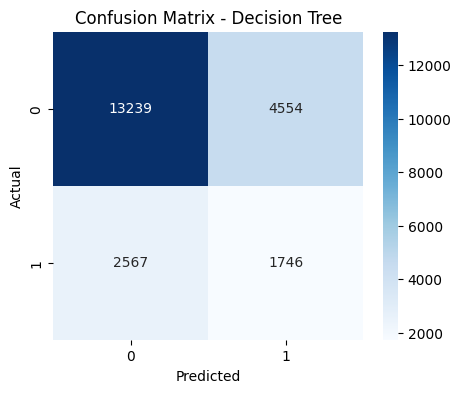



===== Random Forest =====
Accuracy: 0.7224735365963991
Precision: 0.2930486142662426
Recall: 0.2990957570136796
F1 Score: 0.29604130808950085
ROC-AUC: 0.623767961487289


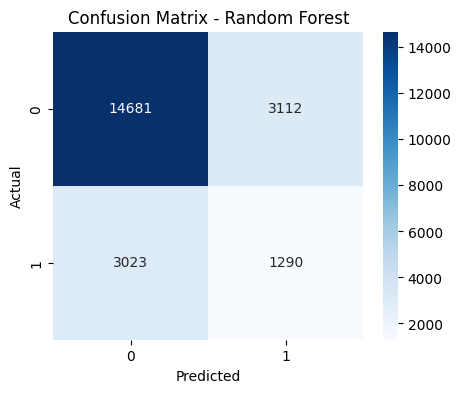



===== Decision Tree (Tuned) =====
Accuracy: 0.5312584818601285
Precision: 0.2767731935936231
Recall: 0.8694644099234872
F1 Score: 0.41988579106483037
ROC-AUC: 0.7034039104075099


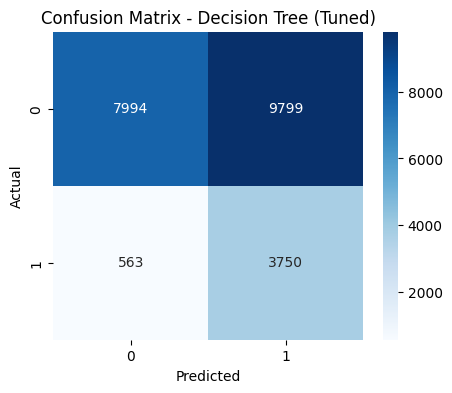



===== Random Forest (Tuned) =====
Accuracy: 0.5232968424862029
Precision: 0.2740143759529514
Recall: 0.8750289821469974
F1 Score: 0.41733937852482583
ROC-AUC: 0.7030646728539293


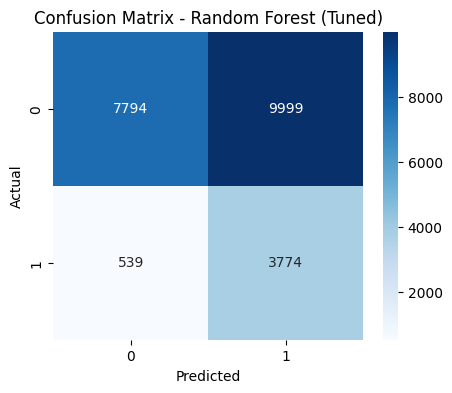

In [29]:
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\n")

print_metrics("Logistic Regression", y_test, y_pred_log, y_prob_log)
print_metrics("Decision Tree", y_test, y_pred_tree, y_prob_tree)
print_metrics("Random Forest", y_test, y_pred_rf, y_prob_rf)

# Tuned Models Evaluation

print_metrics("Decision Tree (Tuned)", y_test, y_pred_tree_tuned, y_prob_tree_tuned)
print_metrics("Random Forest (Tuned)", y_test, y_pred_rf_tuned, y_prob_rf_tuned)

False Negatives are critical in healthcare.
Missing a no-show prediction leads to unprepared clinics and revenue loss.
Hence, Recall is prioritized.

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree)

fp = cm[0,1]
fn = cm[1,0]

print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 4554
False Negatives: 2567


In [31]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='recall'
)

print("Cross Validation Recall Scores:", cv_scores)
print("Mean CV Recall:", cv_scores.mean())

Cross Validation Recall Scores: [0.50660793 0.56702226 0.5300255  0.53721308 0.62601438]
Mean CV Recall: 0.5533766298290494


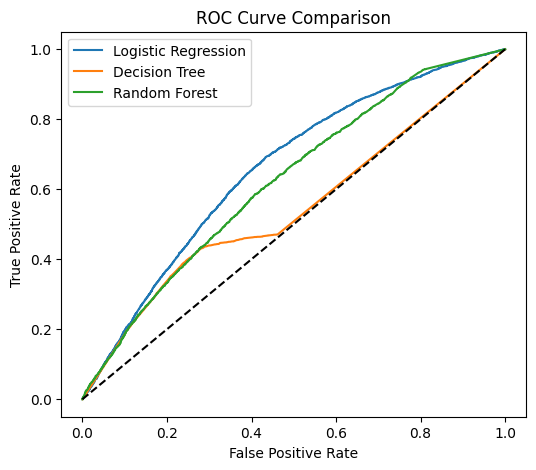

In [32]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

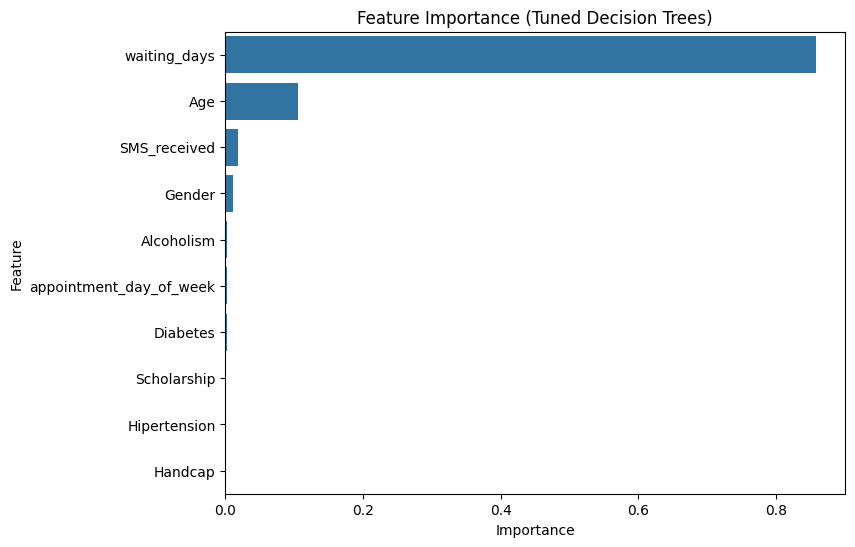

,Feature,Importance
8,waiting_days,0.857467
1,Age,0.105515
7,SMS_received,0.018072
0,Gender,0.011419
5,Alcoholism,0.002578
9,appointment_day_of_week,0.002201
4,Diabetes,0.002136
2,Scholarship,0.000612
3,Hipertension,0.000000
6,Handcap,0.000000


In [33]:
# Feature Importance Decisiom Trees

importances = best_tree_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance (Tuned Decision Trees)")
plt.show()

feature_importance_df.head(10)

In [37]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

comparison_results = {
    "Model": [
        "Logistic Regression (Baseline)",
        "Decision Tree (Baseline)",
        "Random Forest (Baseline)",
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_tree_tuned),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_tree_tuned),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_tree_tuned),
        f1_score(y_test, y_pred_rf_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_tree_tuned),
        precision_score(y_test, y_pred_rf_tuned)
    ]
}

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,Accuracy,Recall,F1 Score,Precision
0,Logistic Regression (Baseline),0.652900,0.555298,0.384338,0.293865
1,Decision Tree (Baseline),0.677870,0.404823,0.329030,0.277143
2,Random Forest (Baseline),0.722474,0.299096,0.296041,0.293049
3,Decision Tree (Tuned),0.531258,0.869464,0.419886,0.276773
4,Random Forest (Tuned),0.523297,0.875029,0.417339,0.274014


## Business Impact

If deployed, the system can:

• Send SMS reminders to high-risk patients  
• Double-book low-risk patients  
• Reduce idle doctor time  
• Improve hospital revenue efficiency  
• Improve patient scheduling optimization  

Based on Recall performance, the Tuned Decision Tree achieved the highest ability to correctly identify no-show patients.

Since false negatives are costly in healthcare (missed no-show prediction leads to revenue loss), Recall was prioritized as the primary evaluation metric.

Therefore, the Tuned Decision Tree model is selected as the final model.

In [35]:
best_model = best_tree_model

import pickle

with open('best_model.pkl', 'wb') as f:
  pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model and scaler saved successfully.')

Model and scaler saved successfully.


In [36]:
print("Best Model Selected:", best_model)

Best Model Selected: DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)


### **Final Conclusion**
Among Logistic Regression, Decision Tree, and Random Forest models, the Tuned Decision Tree achieved the highest Recall score.

Since false negatives are critical in healthcare settings, Recall was chosen as the primary metric.

The Tuned Decision Tree model was therefore selected as the final deployed model.

Feature importance analysis shows that waiting_days is the most influential feature in predicting appointment no-shows.

This system can assist hospitals in:
- Identifying high-risk patients
- Sending targeted reminders
- Reducing revenue loss
- Improving scheduling efficiency


This is a binary classification problem where the target variable indicates whether a patient will attend (0) or not attend (1).